# Week 4 — Baseline Model

## Objectives

- Train a **Linear Regression** model as the first baseline.
- Preserve the chronological train/test split created during Week 3.
- Evaluate performance on the most recent-month test set.
- Save reproducible model results, diagnostic figures, and coefficient estimates.

## Required input

This notebook expects the Week 3 output file:

`results/02/cleaned_preprocessed_data.csv`

The file must contain:

- a target column named `ClosePrice`;
- a column named `split` containing `train` and `test`;
- preprocessed numeric predictor columns.

## Main metric

The required comparison metric is **test-set \(R^2\)**. MAE and RMSE are also reported to make the prediction error easier to interpret.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## 1. Define project folders and load the cleaned dataset

The notebook works when it is stored either:

- inside the repository's `notebooks` folder; or
- in the project root folder.

Generated files are saved in the project's `results/03/` folder.


In [2]:
working_dir = Path.cwd()
project_root = (
    working_dir.parent
    if working_dir.name.lower() == "notebooks"
    else working_dir
)

results_dir = project_root / "results" / "03"
results_dir.mkdir(parents=True, exist_ok=True)

candidate_paths = [
    project_root / "results" / "02" / "cleaned_preprocessed_data.csv",
    project_root / "cleaned_preprocessed_data.csv",
    working_dir / "cleaned_preprocessed_data.csv",
]

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    searched_locations = "\n".join(f"- {path}" for path in candidate_paths)
    raise FileNotFoundError(
        "Could not find cleaned_preprocessed_data.csv.\n"
        "Searched these locations:\n"
        f"{searched_locations}"
    )

df = pd.read_csv(data_path, low_memory=False)
df.columns = df.columns.str.strip()

print(f"Loaded file: {data_path.name}")
print(f"Dataset shape: {df.shape}")
print("Output folder: results/03/")

df.head()


Loaded file: cleaned_preprocessed_data.csv
Dataset shape: (61727, 2449)
Output folder: results/03/


,LivingArea,Bedrooms,Bathrooms,LotSize,YearBuilt,LivingArea_missing,Bedrooms_missing,Bathrooms_missing,LotSize_missing,YearBuilt_missing,CountyOrParish_Alameda,CountyOrParish_Amador,CountyOrParish_Butte,CountyOrParish_Calaveras,CountyOrParish_Colusa,CountyOrParish_Contra Costa,CountyOrParish_El Dorado,CountyOrParish_Foreign Country,CountyOrParish_Fresno,CountyOrParish_Glenn,CountyOrParish_Humboldt,CountyOrParish_Imperial,CountyOrParish_Inyo,CountyOrParish_Kern,CountyOrParish_Kings,CountyOrParish_Lake,CountyOrParish_Lassen,CountyOrParish_Los Angeles,CountyOrParish_Madera,CountyOrParish_Marin,CountyOrParish_Mariposa,CountyOrParish_Mendocino,CountyOrParish_Merced,CountyOrParish_Modoc,CountyOrParish_Mono,CountyOrParish_Monterey,CountyOrParish_Napa,CountyOrParish_Nevada,CountyOrParish_Orange,CountyOrParish_Other,CountyOrParish_Other State,CountyOrParish_Placer,CountyOrParish_Plumas,CountyOrParish_Riverside,CountyOrParish_Sacramento,CountyOrParish_San Benito,CountyOrParish_San Bernardino,CountyOrParish_San Diego,CountyOrParish_San Francisco,CountyOrParish_San Joaquin,...,PostalCode_95948,PostalCode_95949,PostalCode_95953,PostalCode_95954,PostalCode_95958,PostalCode_95961,PostalCode_95963,PostalCode_95965,PostalCode_95966,PostalCode_95968,PostalCode_95969,PostalCode_95971,PostalCode_95973,PostalCode_95979,PostalCode_95988,PostalCode_95991,PostalCode_95993,PostalCode_96001,PostalCode_96002,PostalCode_96003,PostalCode_96007,PostalCode_96019,PostalCode_96021,PostalCode_96022,PostalCode_96025,PostalCode_96029,PostalCode_96035,PostalCode_96041,PostalCode_96044,PostalCode_96052,PostalCode_96055,PostalCode_96063,PostalCode_96067,PostalCode_96073,PostalCode_96080,PostalCode_96088,PostalCode_96091,PostalCode_96092,PostalCode_96093,PostalCode_96094,PostalCode_96097,PostalCode_96101,PostalCode_96106,PostalCode_96114,PostalCode_96130,PostalCode_96137,PostalCode_96143,PostalCode_96150,ClosePrice,split
0,-0.0058,0.5216,-0.5641,-0.0217,-0.3009,-0.0215,0.0000,-0.0045,-0.1340,-0.0242,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,"1,998,000.0000",train
1,0.9636,0.5216,1.1989,-0.0205,-0.6978,-0.0215,0.0000,-0.0045,-0.1340,-0.0242,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,"2,214,421.0000",train
2,-0.4408,0.5216,-0.5641,-0.0219,0.0599,-0.0215,0.0000,-0.0045,-0.1340,-0.0242,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000

## 2. Validate the dataset

This section checks the required columns, duplicate column names, split labels, and target values before model training.


In [3]:
target_col = "ClosePrice"
split_col = "split"

required_cols = [target_col, split_col]
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

duplicate_cols = df.columns[df.columns.duplicated()].tolist()
if duplicate_cols:
    raise ValueError(f"Duplicate column names found: {duplicate_cols[:10]}")

split_values = df[split_col].astype(str).str.strip().str.lower()
valid_split_values = {"train", "test"}
unexpected_values = sorted(set(split_values.dropna()) - valid_split_values)

if unexpected_values:
    raise ValueError(
        f"Unexpected values in '{split_col}': {unexpected_values}. "
        "Expected only 'train' and 'test'."
    )

target_numeric = pd.to_numeric(df[target_col], errors="coerce")

print("Split counts:")
print(split_values.value_counts(dropna=False))

print("\nMissing or nonnumeric target values:", int(target_numeric.isna().sum()))


Split counts:
split
train    49703
test     12024
Name: count, dtype: int64

Missing or nonnumeric target values: 0


## 3. Create chronological training and test masks

The Week 3 preprocessing notebook assigned the most recent month to the test set. This notebook uses that existing split and does **not** perform a random split.


In [4]:
train_mask = split_values.eq("train")
test_mask = split_values.eq("test")

if not train_mask.any() or not test_mask.any():
    raise ValueError(
        "The 'split' column must contain both train and test observations."
    )

print("Training observations:", int(train_mask.sum()))
print("Test observations:", int(test_mask.sum()))


Training observations: 49703
Test observations: 12024


## 4. Build memory-efficient feature matrices

Only numeric columns are used. The target and split columns are excluded.

The feature matrices are stored as `float32` to reduce memory usage. The target remains `float64` for accurate price calculations.


In [5]:
feature_cols = [
    col
    for col in df.columns
    if col not in {target_col, split_col}
    and pd.api.types.is_numeric_dtype(df[col])
]

if not feature_cols:
    raise ValueError("No numeric predictor columns were found.")

X_train = (
    df.loc[train_mask, feature_cols]
    .astype(np.float32, copy=True)
)
X_test = (
    df.loc[test_mask, feature_cols]
    .astype(np.float32, copy=True)
)

y_train = target_numeric.loc[train_mask].astype(np.float64, copy=True)
y_test = target_numeric.loc[test_mask].astype(np.float64, copy=True)

print("Number of predictor columns:", len(feature_cols))
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print(f"X_train memory: {X_train.memory_usage(deep=True).sum() / 1024**2:,.1f} MB")
print(f"X_test memory: {X_test.memory_usage(deep=True).sum() / 1024**2:,.1f} MB")


Number of predictor columns: 2447
X_train shape: (49703, 2447)
X_test shape: (12024, 2447)
X_train memory: 464.3 MB
X_test memory: 112.3 MB


## 5. Handle remaining missing and infinite values

Week 3 should already have handled missing values. This is a final safeguard:

1. Infinite values are converted to missing values.
2. Columns completely missing in the training set are removed.
3. Remaining missing values are filled using **training-set medians only**.

Using training medians avoids information leakage from the test set.


In [6]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

valid_train_target = y_train.notna()
valid_test_target = y_test.notna()

X_train = X_train.loc[valid_train_target].copy()
y_train = y_train.loc[valid_train_target].copy()

X_test = X_test.loc[valid_test_target].copy()
y_test = y_test.loc[valid_test_target].copy()

all_missing_cols = X_train.columns[X_train.isna().all()].tolist()

if all_missing_cols:
    X_train = X_train.drop(columns=all_missing_cols)
    X_test = X_test.drop(columns=all_missing_cols)
    feature_cols = [col for col in feature_cols if col not in all_missing_cols]
    print(f"Dropped {len(all_missing_cols)} all-missing training columns.")

train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

remaining_missing = int(
    X_train.isna().sum().sum()
    + X_test.isna().sum().sum()
)

if remaining_missing:
    raise ValueError(
        f"{remaining_missing} missing feature values remain after imputation."
    )

print("Remaining missing feature values:", remaining_missing)
print("Final number of predictors:", X_train.shape[1])


Remaining missing feature values: 0
Final number of predictors: 2447


## 6. Train the Linear Regression baseline

Linear Regression is intentionally retained as the required baseline. More advanced or regularized models should be compared against this result in later notebooks.


In [7]:
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

print("Linear Regression training completed.")


Linear Regression training completed.


## 7. Generate predictions and evaluate performance

Both training and test metrics are reported. The test metrics determine out-of-sample performance, while the train-test \(R^2\) gap helps identify possible overfitting.


In [8]:
y_train_pred = baseline_model.predict(X_train)
y_test_pred = baseline_model.predict(X_test)

def regression_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
    }

train_metrics = regression_metrics(y_train, y_train_pred)
test_metrics = regression_metrics(y_test, y_test_pred)
r2_gap = train_metrics["R2"] - test_metrics["R2"]

print("Baseline Linear Regression Results")
print("----------------------------------")
print(f"Train R²:  {train_metrics['R2']:.4f}")
print(f"Test R²:   {test_metrics['R2']:.4f}")
print(f"R² gap:    {r2_gap:.4f}")
print(f"Test MAE:  ${test_metrics['MAE']:,.2f}")
print(f"Test RMSE: ${test_metrics['RMSE']:,.2f}")


Baseline Linear Regression Results
----------------------------------
Train R²:  0.0311
Test R²:   0.2463
R² gap:    -0.2152
Test MAE:  $437,599.33
Test RMSE: $1,456,794.30


### Interpretation of \(R^2\)

- \(R^2=1\): perfect predictions.
- \(R^2=0\): performance equal to predicting the mean of the observed test target.
- \(R^2<0\): performance worse than that mean benchmark.

MAE gives the average absolute prediction error. RMSE penalizes unusually large errors more strongly.


## 8. Save the baseline results


In [9]:
baseline_results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "Training_Observations": [len(X_train)],
    "Test_Observations": [len(X_test)],
    "Number_of_Features": [X_train.shape[1]],
    "Train_R2": [train_metrics["R2"]],
    "Test_R2": [test_metrics["R2"]],
    "R2_Gap": [r2_gap],
    "Test_MAE": [test_metrics["MAE"]],
    "Test_RMSE": [test_metrics["RMSE"]],
})

results_path = results_dir / "baseline_model_results.csv"
baseline_results.to_csv(results_path, index=False)

print(f"Saved: results/03/{results_path.name}")
baseline_results


Saved: results/03/baseline_model_results.csv


,Model,Training_Observations,Test_Observations,Number_of_Features,Train_R2,Test_R2,R2_Gap,Test_MAE,Test_RMSE
0,Linear Regression,49703,12024,2447,0.0311,0.2463,-0.2152,"437,599.3263","1,456,794.2974"


## 9. Plot actual versus predicted prices

Points close to the dashed 45-degree line represent more accurate predictions.


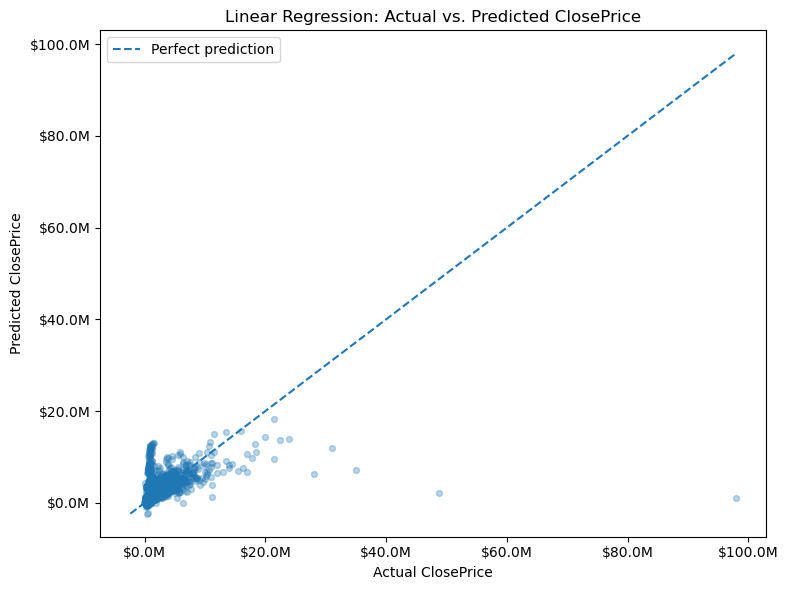

Saved: results/03/baseline_actual_vs_predicted.png


In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_test_pred, alpha=0.30, s=18)

plot_min = min(float(y_test.min()), float(y_test_pred.min()))
plot_max = max(float(y_test.max()), float(y_test_pred.max()))
ax.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--",
    linewidth=1.5,
    label="Perfect prediction",
)

money_formatter = FuncFormatter(lambda value, _: f"${value / 1_000_000:,.1f}M")
ax.xaxis.set_major_formatter(money_formatter)
ax.yaxis.set_major_formatter(money_formatter)

ax.set_xlabel("Actual ClosePrice")
ax.set_ylabel("Predicted ClosePrice")
ax.set_title("Linear Regression: Actual vs. Predicted ClosePrice")
ax.legend()
fig.tight_layout()

figure_path = results_dir / "baseline_actual_vs_predicted.png"
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: results/03/{figure_path.name}")


## 10. Review the largest absolute coefficients

Coefficient magnitude is shown for diagnostic purposes, but it should **not** automatically be treated as feature importance. Correlated predictors and one-hot encoded categories can produce unstable or very large coefficients.


In [11]:
coefficient_table = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": baseline_model.coef_,
})

coefficient_table["Absolute_Coefficient"] = (
    coefficient_table["Coefficient"].abs()
)

coefficient_table = coefficient_table.sort_values(
    "Absolute_Coefficient",
    ascending=False,
).reset_index(drop=True)

coefficient_path = results_dir / "baseline_linear_coefficients.csv"
coefficient_table.to_csv(coefficient_path, index=False)

print(f"Saved: results/03/{coefficient_path.name}")
coefficient_table.head(20)


Saved: results/03/baseline_linear_coefficients.csv


,Feature,Coefficient,Absolute_Coefficient
0,PostalCode_92154,"8,616,682.0000","8,616,682.0000"
1,PostalCode_91911,"6,425,910.0000","6,425,910.0000"
2,City_Montecito,"5,481,126.0000","5,481,126.0000"
3,City_Valley Center,"5,026,830.0000","5,026,830.0000"
4,PostalCode_92082,"5,026,826.0000","5,026,826.0000"
5,PostalCode_92532,"4,374,742.0000","4,374,742.0000"
6,PostalCode_93108,"4,311,855.0000","4,311,855.0000"
7,PostalCode_92657,"3,728,103.7500","3,728,103.7500"
8,City_Newport Coast,"3,728,103.2500","3,728,103.2500"
9,PostalCode_90210,"3,571,046.7500","3,571,046.7500"


## Conclusion

This notebook establishes the Week 4 Linear Regression baseline using the chronological split created during preprocessing.

Use the **test-set \(R^2\)** as the primary comparison point for later models. The train-test gap, MAE, and RMSE provide additional evidence about generalization and prediction error.

Generated files:

- `results/03/baseline_model_results.csv`
- `results/03/baseline_actual_vs_predicted.png`
- `results/03/baseline_linear_coefficients.csv`

Before uploading the notebook to GitHub, run all cells from top to bottom and save the notebook so the outputs are embedded.
